## Clase 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

Se utiliza la palabraa DF para definir la funcion que leera toda la dataset en la nomblegatura.

In [4]:
df = pd.read_csv('diabetes_risk_prediction_dataset.csv')

Usamos la funcion .head para saber todos los cabezales de la base de datos.

In [5]:
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High


shape nos da el total de registros y la cantidad de columnas que tenemos.

In [6]:
df.shape

(50000, 41)

El .info() nos da todos los datos de nuestros atributos.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  str    
 3   Country                     50000 non-null  str    
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diastolic    50000 non-null

.describe() nos da la descripcion total de todos los campos necesarios que tenemos en nuestra dataset.

In [8]:
df.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,25000.500000,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,14433.901067,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,1.000000,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,12500.750000,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,25000.500000,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,37500.250000,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,50000.000000,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


.isnullnos da todos los registros nulos o varios de nuestros atributos.

In [9]:
df.isnull().sum()

Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Family_History_Diabe

In [10]:
df["Blood_Glucose"].fillna(df["Age"].mode()[0], inplace=True)

/tmp/ipykernel_3874/605118891.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Blood_Glucose"].fillna(df["Age"].mode()[0], inplace=True)


0         88.4
1        247.3
2        141.9
3         90.1
4         93.8
         ...  
49995    248.8
49996    198.4
49997    118.8
49998    139.5
49999    123.5
Name: Blood_Glucose, Length: 50000, dtype: float64

In [11]:
import missingno as msno

<Axes: >

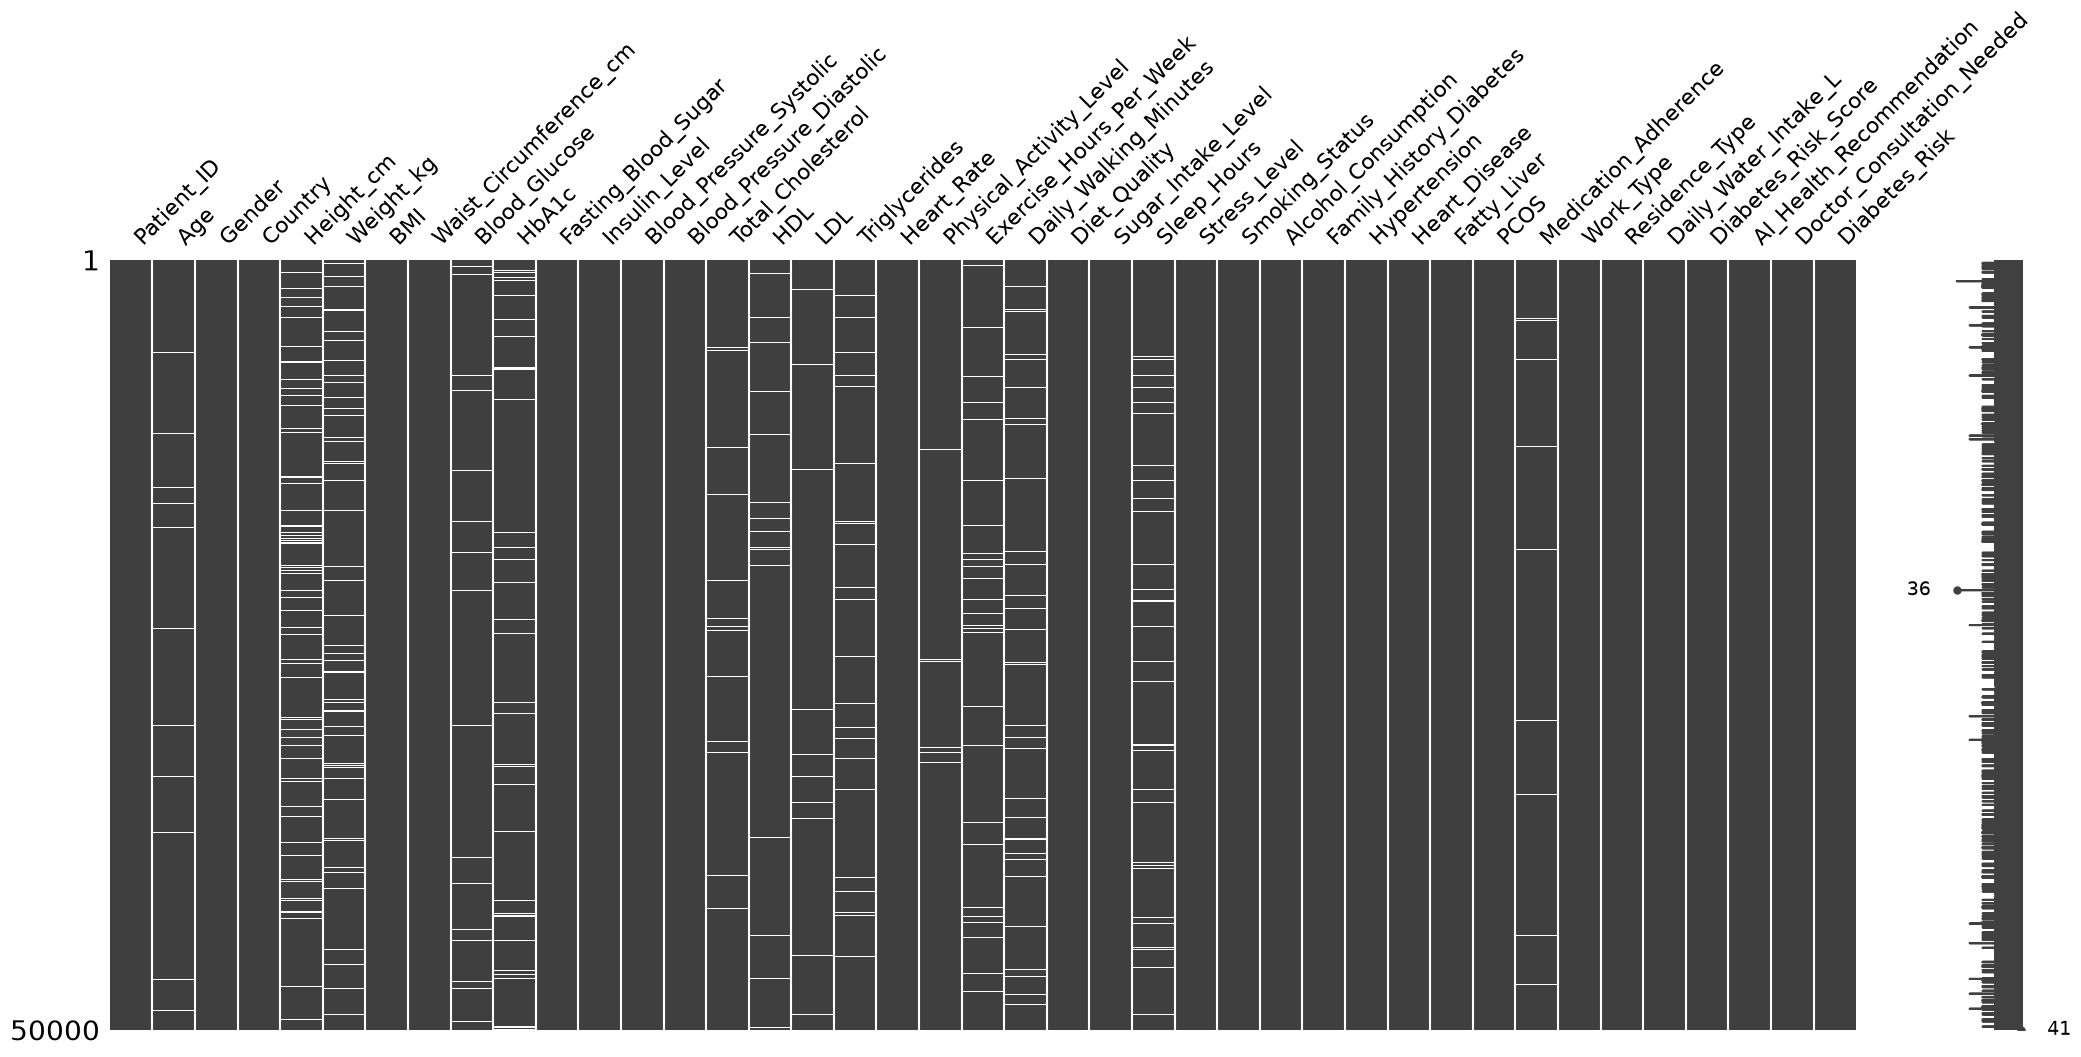

In [12]:
msno.matrix(df)

En este caso decimos que solo queremos saber mi dataset.

In [14]:
df[df["Blood_Glucose"]=="Physical_Activity_Level"]

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
